In [1]:
def displayReconOrthogonalSlices(recon):
    import matplotlib.pyplot as plt
    nz, ny, nx = recon.shape
    cx, cy, cz = nx // 2, ny // 2, nz // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(recon[cz, :, :], cmap='gray', aspect='equal')
    axes[0].set_title(f'XY  (z={cz})')

    axes[1].imshow(recon[:, cy, :], cmap='gray', aspect='auto')
    axes[1].set_title(f'XZ  (y={cy})')

    axes[2].imshow(recon[:, :, cx], cmap='gray', aspect='auto')
    axes[2].set_title(f'YZ  (x={cx})')

    for ax in axes:
        ax.axis('off')

    plt.suptitle('Orthogonal slices through reconstruction')
    plt.tight_layout()
    plt.show()

In [ ]:
# #Upload tiff of alignedProjection
# fileLocation = "/home/ljh79/TomoMono/alignedProjections/APSbeamtime_Oct25/cfg_fullres_aligned_20260514-115952.tif"
# from helperFunctions import convert_to_numpy, MoviePlotter
# alignedProjection = convert_to_numpy(fileLocation)[0]

# from helperFunctions import MoviePlotter
# print(alignedProjection.shape)
# MoviePlotter(alignedProjection, color="gist_ncar")

[gpu] active backends: numpy, svmbir


/home/ljh79/.conda/envs/tomoMono/lib/python3.12/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA driver initialization failed, you might not have a CUDA gpu. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


[gpu] active backends: numpy, svmbir
(400, 1200, 1200)


Output()

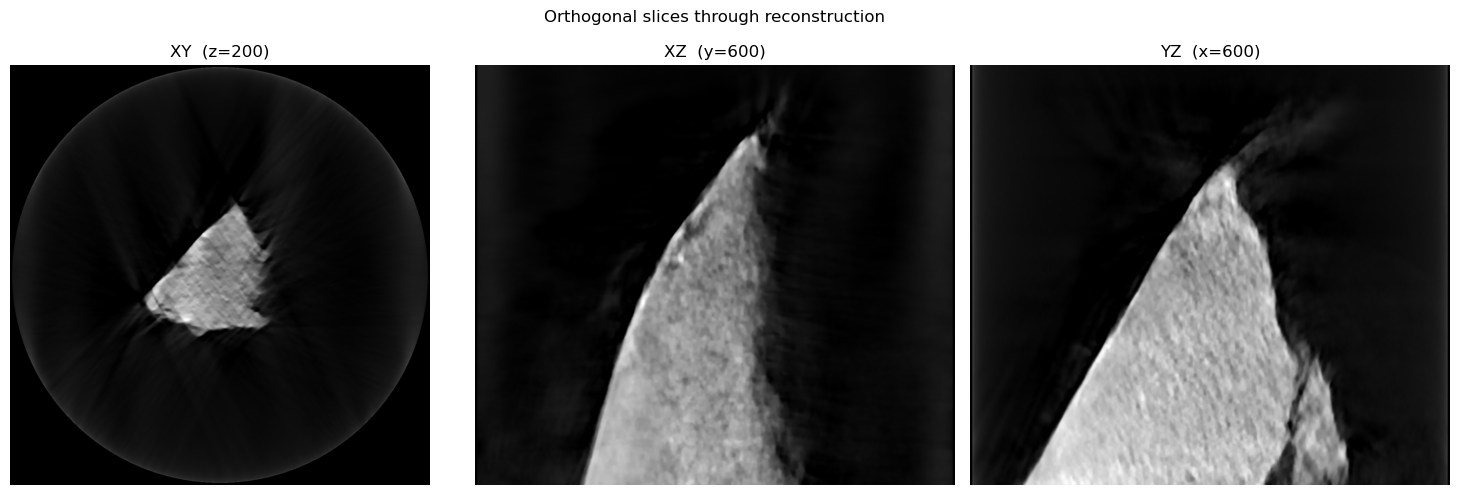

In [2]:
#Upload tiff of reconstruction
fileLocation = "/home/ljh79/TomoMono/reconstructions/APSbeamtime_Oct25/svmbir/svmbir_recons_20260518-095553/svmbir_maxres_3_20260518-095553.tif"
from helperFunctions import convert_to_numpy, MoviePlotter
reconstruction = convert_to_numpy(fileLocation)[0]

from helperFunctions import MoviePlotter
print(reconstruction.shape)
MoviePlotter(reconstruction, color="gray")

displayReconOrthogonalSlices(reconstruction)

In [3]:
import h5py
import numpy as np
# ANGLE_PATH = "/Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2.hdf5"
ANGLE_PATH = '/home/ljh79/groups/grp_ptychi/nobackup/autodelete/Oct2025APSdata/tomo_data_run_final_2.hdf5'

with h5py.File(ANGLE_PATH) as f:
    angles = f['angles'][...] * np.pi / 180
    angles = angles - np.mean(angles)  # Shift angles to be centered around 0

print(f'Angles      : {len(angles)}  [{np.degrees(angles.min()):.1f}°, {np.degrees(angles.max()):.1f}°]')


Angles      : 558  [-65.4°, 65.4°]


In [4]:
from tomoDataClass import *
tomo = tomoData(np.zeros((1,1,1)),angles)
tomo.recon = reconstruction


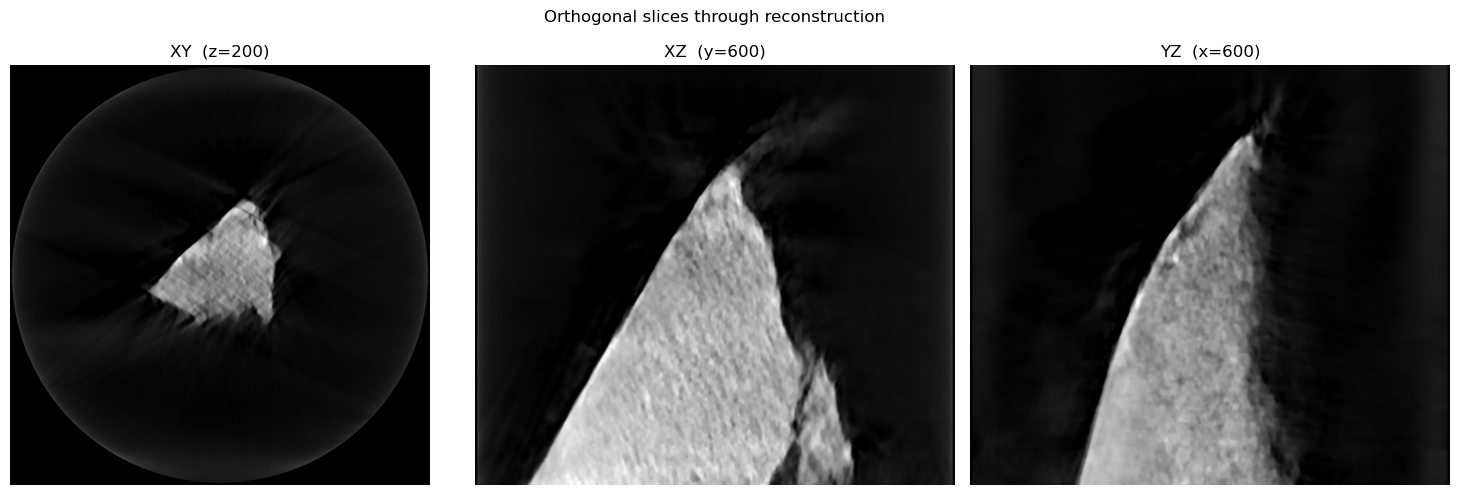

In [ ]:
def correct_svmbir_geometry(recon):
    """Align SVMBIR reconstruction to TomoPy coordinate system."""
    # # Flip horizontally (mirror in XY plane)
    recon = np.flip(recon, axis=2)  # flip x-axis 
    # Rotate 90° in XY plane
    recon = np.rot90(recon, k=1, axes=(1, 2))
    return recon

displayReconOrthogonalSlices(correct_svmbir_geometry(reconstruction))



Applying Kovacik filter to slice(s) 250–250...


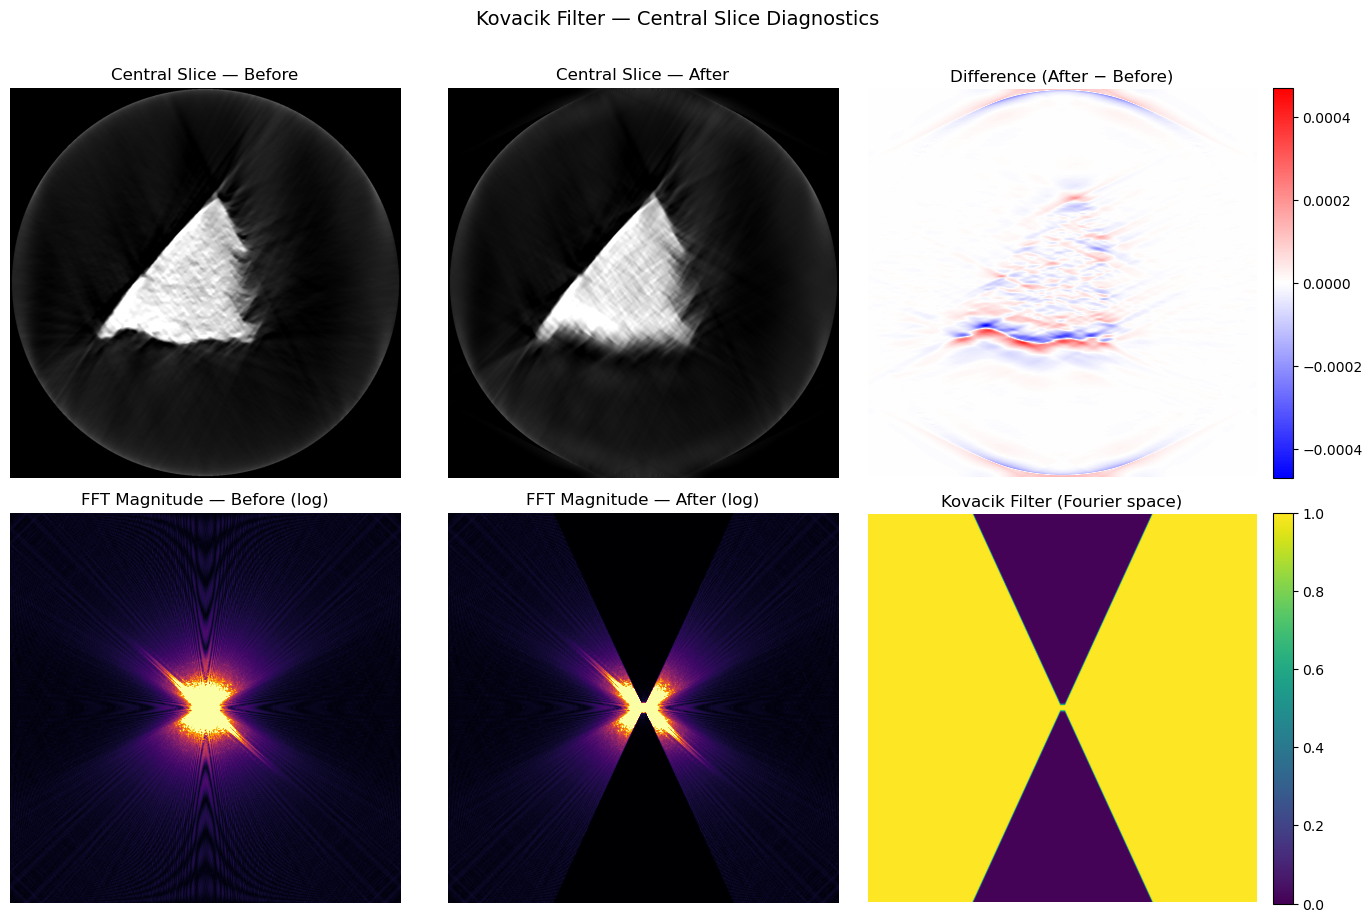

Kovacik filter applied.


In [5]:
tomo.kovacik_filter(mwr_length=2, mwr_order=2, mwr_wmin=0.01,
                   cs_order=4, cs_cutoff=10,
                   plot=True, plotSlice=250, only_slice=250)